# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Business Understanding
Goal: ?

## Business Problem

Lifestyle factors such as sleep, exercise, stress, working hours, screen time
and social interaction may affect a person's happiness and overall well-being.
However, it can be difficult for individuals to understand how these factors
work together.

This project develops a machine learning solution that predicts a person's
Happiness Score using demographic and lifestyle information.

## Machine Learning Goal

The goal is to develop a regression model that predicts the numerical
`Happiness Score`.

This is a regression problem because Happiness Score is a continuous numerical
value rather than a fixed category.

## Target Users and Business Value

The target users are individuals who want to understand how their lifestyle
habits may relate to their general well-being.

The solution provides users with a quick estimate of their Happiness Score and
encourages them to reflect on lifestyle areas such as sleep, stress, exercise
and social interaction.

The prediction is intended for general wellness awareness only and should not
be treated as medical advice or a mental-health diagnosis.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
FILE_PATH = r"C:\Users\haniy\OneDrive\Desktop\MLDP\Mental_Health_Lifestyle_Dataset.csv"
df = pd.read_csv(FILE_PATH) 
df ## Display dataframe

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Japan,57,Female,Moderate,Balanced,7.0,High,Depression,29,4.4,9.7,5.9
2996,Australia,27,Male,Low,Junk Food,7.1,Low,NaN,47,7.4,6.3,9.9
2997,Australia,42,Male,Moderate,Balanced,6.0,High,Depression,23,3.9,5.2,4.1
2998,Australia,25,Male,High,Keto,5.7,Low,Anxiety,51,4.3,5.9,4.1


### Dataset Description

The dataset contains 3,000 records and 12 columns describing demographic,
lifestyle and well-being information.

The target variable is `Happiness Score`. The remaining columns may be used as
input features for model training.

The dataset was selected because it contains more than the required 200
records, includes both numerical and categorical features, and supports a
regression machine learning problem.

Dataset source: [https://www.kaggle.com/datasets/atharvasoundankar/mental-health-and-lifestyle-habits-2019-2024]

The dataset must be approved by the tutor before final model development.

## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      3000 non-null   object 
 1   Age                          3000 non-null   int64  
 2   Gender                       3000 non-null   object 
 3   Exercise Level               3000 non-null   object 
 4   Diet Type                    3000 non-null   object 
 5   Sleep Hours                  3000 non-null   float64
 6   Stress Level                 3000 non-null   object 
 7   Mental Health Condition      2405 non-null   object 
 8   Work Hours per Week          3000 non-null   int64  
 9   Screen Time per Day (Hours)  3000 non-null   float64
 10  Social Interaction Score     3000 non-null   float64
 11  Happiness Score              3000 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 281.4+ KB


### Dataset Structure

The dataset contains 3,000 observations and 12 original variables.

Numerical variables include Age, Sleep Hours, Work Hours per Week, Screen Time
per Day, Social Interaction Score and Happiness Score.

Categorical variables include Country, Gender, Exercise Level, Diet Type,
Stress Level and Mental Health Condition.

Happiness Score is stored as a numerical variable, confirming that this is a
regression problem.

In [4]:
## Check for missing data
# Check for missing data
df.isnull().sum()

Country                          0
Age                              0
Gender                           0
Exercise Level                   0
Diet Type                        0
Sleep Hours                      0
Stress Level                     0
Mental Health Condition        595
Work Hours per Week              0
Screen Time per Day (Hours)      0
Social Interaction Score         0
Happiness Score                  0
dtype: int64

### Missing Values

The missing-value check shows that missing data is present in the
`Mental Health Condition` column.

The other columns do not contain missing values.

Instead of deleting the affected rows, the missing values will be replaced
with `None Reported`. This retains the useful lifestyle information in those
records and provides a meaningful category for users without a recorded
condition.

In [5]:
## Describe data distribution
# Check for missing data
# Describe data distribution
df.describe(include='all')

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
count,3000,3000.000000,3000,3000,3000,3000.000000,3000,2405,3000.000000,3000.000000,3000.000000,3000.000000
unique,7,NaN,3,3,5,NaN,3,4,NaN,NaN,NaN,NaN
top,USA,NaN,Female,Low,Junk Food,NaN,Low,Anxiety,NaN,NaN,NaN,NaN
freq,446,NaN,1024,1033,637,NaN,1008,628,NaN,NaN,NaN,NaN
mean,NaN,41.229667,NaN,NaN,NaN,6.475933,NaN,NaN,39.466333,5.089833,5.470200,5.395067
std,NaN,13.428416,NaN,NaN,NaN,1.499866,NaN,NaN,11.451459,1.747231,2.563532,2.557601
min,NaN,18.000000,NaN,NaN,NaN,1.400000,NaN,NaN,20.000000,2.000000,1.000000,1.000000
25%,NaN,30.000000,NaN,NaN,NaN,5.500000,NaN,NaN,30.000000,3.600000,3.300000,3.200000
50%,NaN,41.000000,NaN,NaN,NaN,6.500000,NaN,NaN,39.000000,5.100000,5.500000,5.400000
75%,NaN,53.000000,NaN,NaN,NaN,7.500000,NaN,NaN,50.000000,6.600000,7.600000,7.500000


### Summary Statistics

The summary statistics show the distributions, ranges and most common values
of the dataset variables.

The numerical variables use different measurement scales. For example, Age,
Work Hours, Screen Time and Happiness Score have different ranges. Therefore,
standardisation will be included during preprocessing for models that may be
affected by feature scale.

The categorical statistics also help identify the number of unique categories
and whether certain categories appear more frequently than others.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

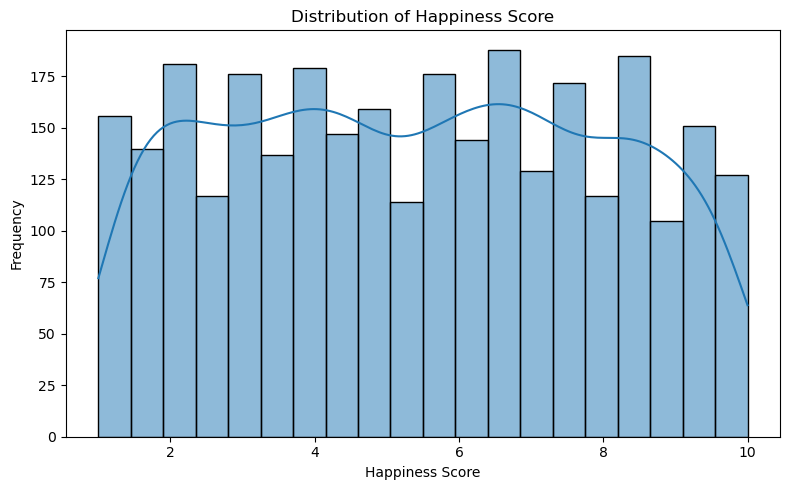

In [6]:
## Display the distribution of Happiness Score
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Happiness Score",
    bins=20,
    kde=True
)

plt.title("Distribution of Happiness Score")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Target Distribution Interpretation

The histogram shows how Happiness Score values are distributed throughout the
dataset.

The scores are spread across the available range rather than being concentrated
around only one value. This means that the model must learn to predict many
different Happiness Score values.

The chart also helps identify whether the target is heavily skewed or contains
unusual values that may affect model training.

### 2.3.1.2 Understanding distribution of features

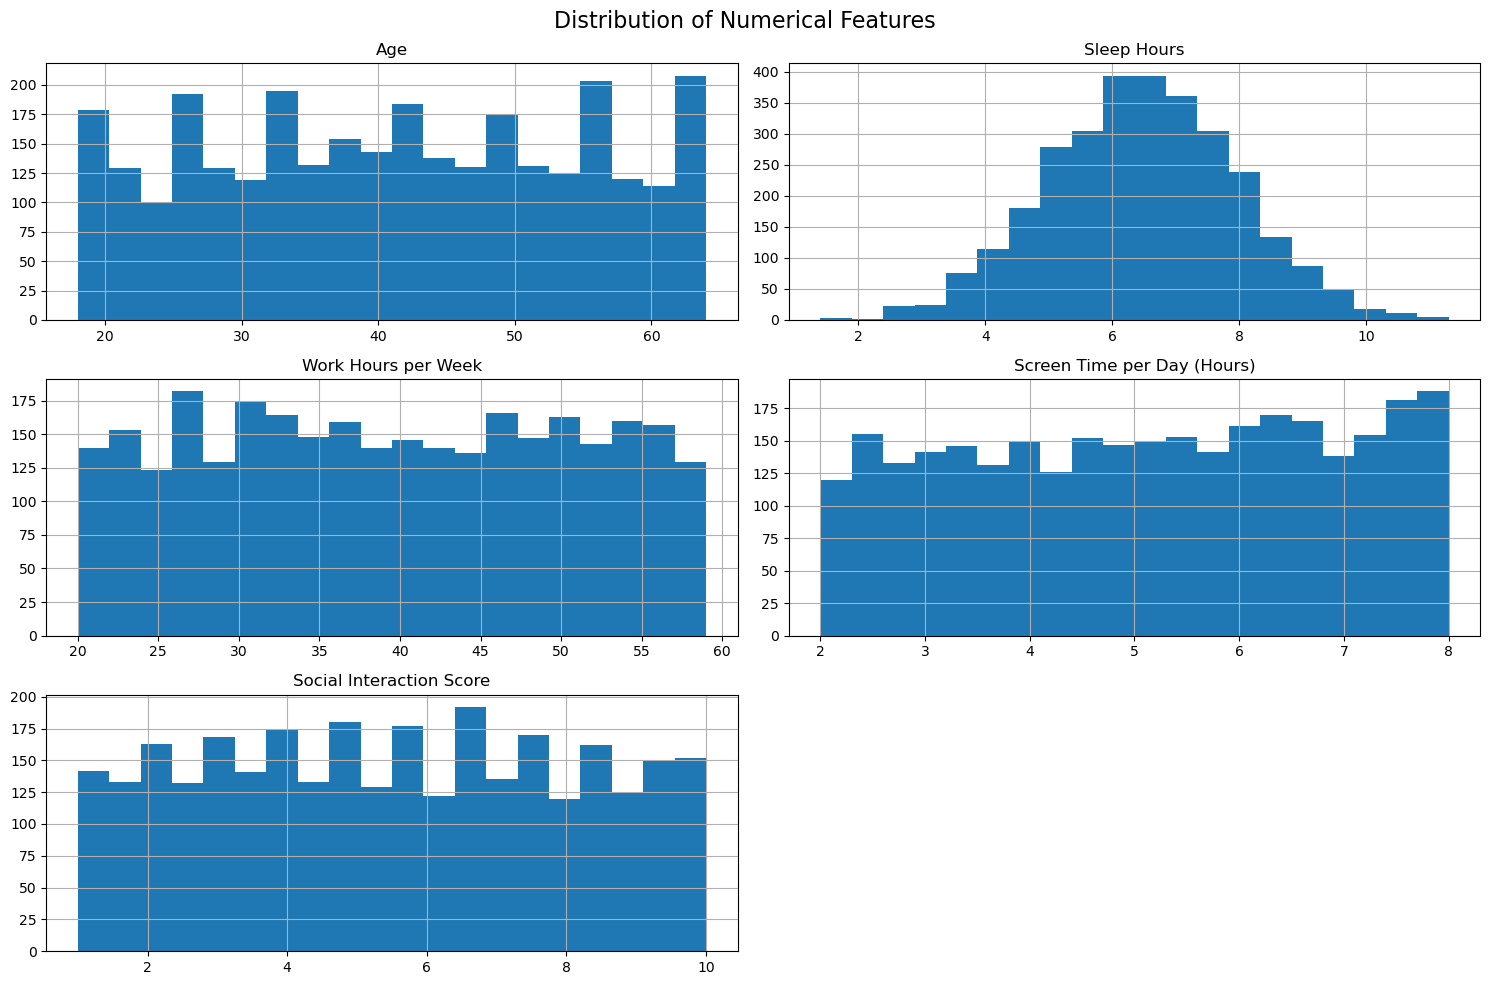

In [7]:
## Understanding distribution of numerical features

# Select only numerical input features, excluding Happiness Score
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
numerical_features = numerical_features.drop("Happiness Score")

# Plot histograms for the numerical input features
df[numerical_features].hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Numerical Feature Distribution Interpretation

The histograms show the distributions of the numerical lifestyle and
demographic variables.

These graphs help identify the ranges, common values, skewness and possible
outliers in each feature.

Understanding these distributions is important because unusual values may
affect model performance, while different feature scales may require
standardisation during preprocessing.

### 2.3.2 Understanding relationship between variables

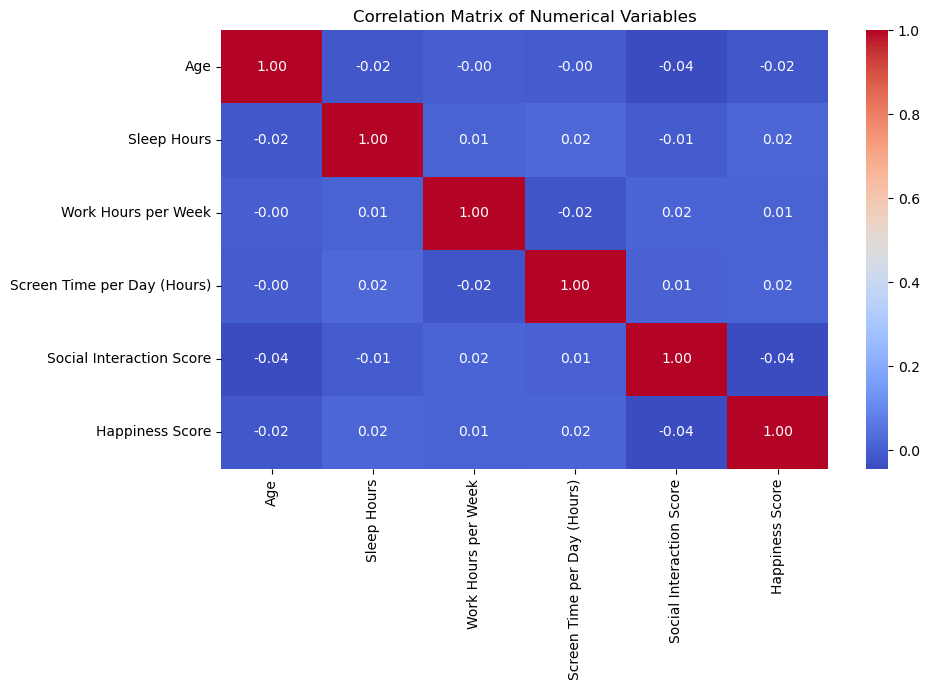

In [8]:
## Correlation heatmap

correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Correlation Interpretation

The heatmap shows the strength and direction of the linear relationships
between the numerical variables.

Correlation values close to 1 indicate a strong positive relationship, while
values close to -1 indicate a strong negative relationship. Values close to
0 indicate a weak linear relationship.

The correlations with Happiness Score appear weak. This suggests that no
single numerical feature strongly explains the target on its own.

However, weak correlation does not automatically mean a feature is useless,
because tree-based models can also capture non-linear relationships and
interactions between variables.

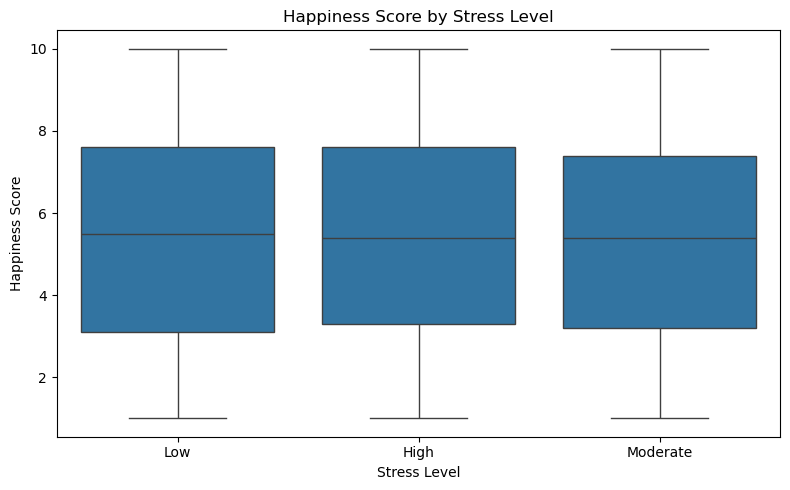

In [9]:
## Compare Happiness Score across different Stress Levels

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Stress Level",
    y="Happiness Score"
)

plt.title("Happiness Score by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Happiness Score")
plt.tight_layout()
plt.show()

### Stress Level and Happiness Score

The box plot compares the Happiness Score distributions of participants with
different stress levels.

The median, spread and overlap of the groups show whether Stress Level may
provide useful information for predicting happiness.

Any observed relationship represents an association only. It does not prove
that stress directly causes a particular Happiness Score.

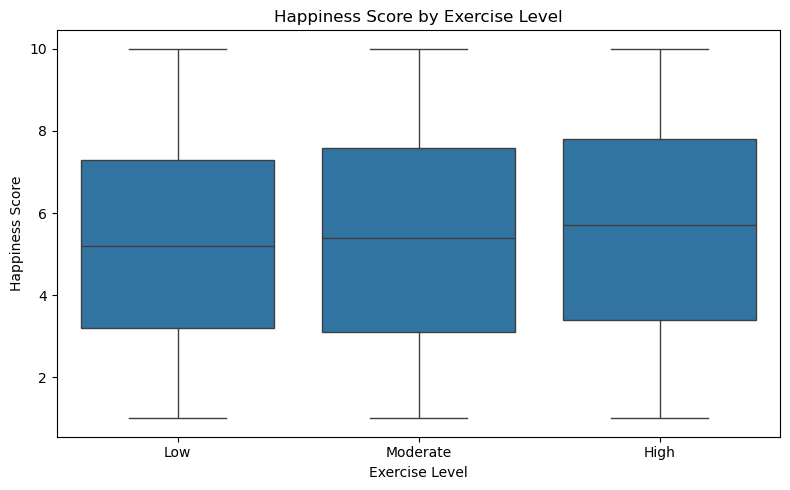

In [10]:
## Compare Happiness Score across different Exercise Levels

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Exercise Level",
    y="Happiness Score"
)

plt.title("Happiness Score by Exercise Level")
plt.xlabel("Exercise Level")
plt.ylabel("Happiness Score")
plt.tight_layout()
plt.show()

### Exercise Level and Happiness Score

The box plot compares Happiness Score across the different Exercise Level
categories.

Differences between the median scores may indicate that Exercise Level contains
useful predictive information. However, substantial overlap between the groups
would mean that Exercise Level alone is not enough to predict happiness
accurately.

The feature will still be evaluated together with the other lifestyle
variables during model training.

# 3. Data Preparation

## 3.1 Data Cleaning

In [11]:
## Clean data
## Create a copy of the dataset before cleaning
df_cleaned = df.copy()

## Remove duplicated rows
df_cleaned = df_cleaned.drop_duplicates()

## Replace missing values in Mental Health Condition
df_cleaned["Mental Health Condition"] = (
    df_cleaned["Mental Health Condition"]
    .fillna("None Reported")
)

## Check the cleaned dataset
print("Number of rows after cleaning:", df_cleaned.shape[0])
print("Total missing values:", df_cleaned.isnull().sum().sum())

df_cleaned.head()

Number of rows after cleaning: 3000
Total missing values: 0


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,None Reported,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,None Reported,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


### Data-Cleaning Rationale

A copy of the original dataset was created before cleaning so that the raw
data remained unchanged.

Duplicated rows were removed because repeated observations could unfairly
influence the model.

Missing values in `Mental Health Condition` were replaced with
`None Reported`. This approach retains the affected records instead of
discarding their other useful lifestyle information.

After cleaning, the dataset was checked again to ensure that no missing values
remained.

In [12]:
## Create new lifestyle-related features

# Difference between actual sleep hours and 8 hours
df_cleaned["Sleep Deviation"] = (
    df_cleaned["Sleep Hours"] - 8
).abs()

# Combined daily workload and screen exposure
df_cleaned["Work Screen Load"] = (
    df_cleaned["Work Hours per Week"] / 7
    + df_cleaned["Screen Time per Day (Hours)"]
)

# Convert Exercise Level into numbers
exercise_mapping = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}

df_cleaned["Exercise Level Numeric"] = (
    df_cleaned["Exercise Level"]
    .map(exercise_mapping)
)

# Combine exercise and social interaction
df_cleaned["Active Social Score"] = (
    df_cleaned["Exercise Level Numeric"]
    * df_cleaned["Social Interaction Score"]
)

df_cleaned.head()

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score,Sleep Deviation,Work Screen Load,Exercise Level Numeric,Active Social Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,None Reported,21,4.0,7.8,6.5,1.7,7.000000,1,7.8
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8,3.1,12.057143,2,16.4
2,Japan,37,Female,Low,Vegetarian,7.2,High,None Reported,43,4.7,9.6,9.7,0.8,10.842857,1,9.6
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6,0.8,8.342857,1,8.2
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4,0.7,8.600000,1,4.7


### Feature-Engineering Rationale

Three additional lifestyle features were created.

`Sleep Deviation` measures how far a participant's sleep duration is from
eight hours. This allows the model to consider that both shorter and longer
sleep durations differ from the reference value.

`Work Screen Load` combines average daily working hours with daily screen time.
It represents the participant's combined workload and digital exposure.

`Active Social Score` combines exercise level with social interaction. It
represents the possible combined effect of physical activity and social
engagement.

The original variables were retained so that model performance with the
engineered features could be evaluated.

## 3.2 Train-Test Split

In [13]:
## Split data into train set and test set
## Separate input features and target variable

X = df_cleaned.drop(columns=["Happiness Score"])
y = df_cleaned["Happiness Score"]

## Remove the temporary numeric exercise column
## because the original Exercise Level column will be encoded later
X = X.drop(columns=["Exercise Level Numeric"])

## Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2400, 14)
Testing data: (600, 14)


### Train-Test Split

The dataset was divided into 80% training data and 20% testing data.

The training set is used to train the machine learning models. The test set is
kept separate and unseen during training so that it can provide a fair
evaluation of performance on new data.

A random state of 42 was used to ensure that the same split can be reproduced
when the notebook is run again.

In [14]:
## Identify numerical and categorical columns

numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Age', 'Sleep Hours', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Sleep Deviation', 'Work Screen Load', 'Active Social Score']

Categorical columns:
['Country', 'Gender', 'Exercise Level', 'Diet Type', 'Stress Level', 'Mental Health Condition']


### Feature Types

The input variables were separated into numerical and categorical columns
because they require different preprocessing methods.

Numerical variables can be represented directly as numbers, while categorical
variables must be converted into a machine-readable numerical format before
they can be used by the models.

In [15]:
## Import preprocessing tools

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [16]:
## Create preprocessing steps

# Numerical columns:
# Fill missing values using the median and standardise the values
numerical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical columns:
# Fill missing values using the most common category
# and convert text categories into numerical columns
categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Apply the correct preprocessing to each column type
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_preprocessor, numerical_columns),
        ("categorical", categorical_preprocessor, categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Preprocessing

Numerical missing values are handled using median imputation. StandardScaler is
then used to place numerical features on comparable scales.

Categorical missing values are handled using the most frequent category.
One-hot encoding converts each categorical value into numerical indicator
columns.

`handle_unknown="ignore"` prevents the model from crashing if the deployed
application receives a category that was not present during training.

A ColumnTransformer applies the appropriate preprocessing method to each
column type while preventing manual and inconsistent transformations.

# 4. Modelling

In [17]:
## Import regression models

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [18]:
## Create the baseline and candidate models

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

models = {
    "Baseline": baseline_model,
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

print("Models created successfully.")

Models created successfully.


## 4.1 Model Selection

Four models were created for comparison.

The Dummy Regressor is used as a baseline. It predicts the average Happiness
Score and represents the minimum performance that a useful model should
exceed.

Linear Regression was selected as a simple and interpretable model for
identifying approximately linear relationships.

Random Forest was selected because it can capture non-linear relationships and
interactions between lifestyle variables.

Gradient Boosting was selected because it builds trees sequentially and
attempts to correct the errors made by earlier trees.

Using different algorithms allows the final model to be selected using
evidence rather than assumption.

### 4.2 Train Model

In [19]:
## Initialise and train model
## Train all models

for model_name, model in models.items():
    print(f"Training {model_name}...")

    model.fit(X_train, y_train)

    print(f"{model_name} trained successfully.\n")

Training Baseline...
Baseline trained successfully.

Training Linear Regression...
Linear Regression trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training Gradient Boosting...
Gradient Boosting trained successfully.



### Model Training

All candidate models were trained using the same training dataset.

Each model was placed inside a pipeline containing the preprocessing steps.
This ensures that the same transformations are applied consistently during
training, testing and future Streamlit predictions.

# 5. Model Evaluation

In [20]:
## Evaluate model
## Evaluate model

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

model_results = []

for model_name, model in models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="MAE"
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.243414,2.608011,-0.004783
1,Random Forest,2.254673,2.622715,-0.016145
2,Baseline,2.256277,2.601851,-0.000042
3,Gradient Boosting,2.262994,2.624474,-0.017508


### Evaluation Metrics

Mean Absolute Error, Root Mean Squared Error and R² were used to evaluate the
regression models.

MAE is the main business metric because it shows the average number of
Happiness Score points by which a prediction differs from the actual value.
A lower MAE indicates better performance.

RMSE also measures prediction error but penalises large errors more strongly.
A lower RMSE is therefore preferred.

R² measures how much of the variation in Happiness Score is explained by the
model. A value closer to 1 is better. A value close to 0 means the model
explains little more than predicting the average, while a negative value means
that it performs worse than the baseline mean prediction.

In [21]:
## Test the best-performing model using one row from the test data

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

new_data = X_test.iloc[[0]]
actual_score = y_test.iloc[0]

predicted_score = best_model.predict(new_data)[0]

print("Best model:", best_model_name)
print("Actual Happiness Score:", round(actual_score, 2))
print("Predicted Happiness Score:", round(predicted_score, 2))
print(
    "Absolute Error:",
    round(abs(actual_score - predicted_score), 2)
)


Best model: Linear Regression
Actual Happiness Score: 5.6
Predicted Happiness Score: 5.16
Absolute Error: 0.44


### Sample Prediction

One record from the test set was used to confirm that the selected model can
successfully process new input and produce a numerical Happiness Score
prediction.

The actual and predicted scores were displayed together with their absolute
difference. This provides a simple example of how the model will behave after
deployment.

## Iterative model development


In [22]:
## Further feature engineering / feature selection
## Compare original features against engineered features

engineered_features = [
    "Sleep Deviation",
    "Work Screen Load",
    "Active Social Score"
]

# Create a version without the engineered features
X_basic = df_cleaned.drop(
    columns=[
        "Happiness Score",
        "Exercise Level Numeric"
    ] + engineered_features
)

y_basic = df_cleaned["Happiness Score"]

# Split the basic feature set
X_train_basic, X_test_basic, y_train_basic, y_test_basic = train_test_split(
    X_basic,
    y_basic,
    test_size=0.2,
    random_state=42
)

# Identify basic numerical and categorical columns
basic_numerical_columns = X_train_basic.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

basic_categorical_columns = X_train_basic.select_dtypes(
    include=["object"]
).columns.tolist()

# Create preprocessing for the basic feature set
basic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            basic_numerical_columns
        ),
        (
            "categorical",
            categorical_preprocessor,
            basic_categorical_columns
        )
    ]
)

# Random Forest using only original features
basic_model = Pipeline(
    steps=[
        ("preprocessor", basic_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Random Forest using original + engineered features
engineered_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train both models
basic_model.fit(X_train_basic, y_train_basic)
engineered_model.fit(X_train, y_train)

# Make predictions
basic_predictions = basic_model.predict(X_test_basic)
engineered_predictions = engineered_model.predict(X_test)

# Compare results
feature_results = pd.DataFrame({
    "Feature Set": [
        "Original Features",
        "Original + Engineered Features"
    ],
    "MAE": [
        mean_absolute_error(y_test_basic, basic_predictions),
        mean_absolute_error(y_test, engineered_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_basic, basic_predictions)),
        np.sqrt(mean_squared_error(y_test, engineered_predictions))
    ],
    "R2 Score": [
        r2_score(y_test_basic, basic_predictions),
        r2_score(y_test, engineered_predictions)
    ]
})

feature_results

,Feature Set,MAE,RMSE,R2 Score
0,Original Features,2.259622,2.616923,-0.011662
1,Original + Engineered Features,2.254673,2.622715,-0.016145


### Feature-Engineering Comparison

The Random Forest model using only the original features achieved an MAE of
approximately 2.2596.

The model using the original and engineered features achieved a slightly lower
MAE of approximately 2.2547. However, its RMSE and R² were slightly worse.

Therefore, the engineered features produced only a very small MAE improvement
and did not clearly improve the model across all evaluation metrics.

This result shows that feature engineering was tested and evaluated rather
than automatically assumed to improve model performance.

In [23]:
## Hyperparameter tuning using RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

parameter_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=parameter_grid,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print(
    "Best cross-validation MAE:",
    round(-random_search.best_score_, 4)
)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__max_depth': 10}
Best cross-validation MAE: 2.218


### Hyperparameter-Tuning Rationale

RandomizedSearchCV was used to tune the Random Forest model.

The search varied the number of trees, maximum tree depth and minimum number
of samples required to split a node. Each hyperparameter contained no more
than three possible values, following the project requirements.

Five-fold cross-validation was used so that the parameter combinations were
tested across multiple training and validation splits.

MAE was used as the tuning score because it has a direct and understandable
relationship with the prediction error experienced by users.

In [24]:
## Evaluate tuned Random Forest model

tuned_model = random_search.best_estimator_

tuned_predictions = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print("Tuned Random Forest Results")
print("MAE:", round(tuned_mae, 4))
print("RMSE:", round(tuned_rmse, 4))
print("R2 Score:", round(tuned_r2, 4))

Tuned Random Forest Results
MAE: 2.2452
RMSE: 2.5975
R2 Score: 0.0033


In [25]:
## Compare untuned and tuned Random Forest

untuned_rf_results = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]

tuning_comparison = pd.DataFrame({
    "Model": [
        "Untuned Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        untuned_rf_results["MAE"],
        tuned_mae
    ],
    "RMSE": [
        untuned_rf_results["RMSE"],
        tuned_rmse
    ],
    "R2 Score": [
        untuned_rf_results["R2 Score"],
        tuned_r2
    ]
})

tuning_comparison

,Model,MAE,RMSE,R2 Score
0,Untuned Random Forest,2.254673,2.622715,-0.016145
1,Tuned Random Forest,2.245243,2.597514,0.003289


### Tuning Comparison

The tuned Random Forest achieved better overall results than the untuned
Random Forest.

The tuning process reduced prediction error and produced an R² value slightly
above zero. This shows that the selected hyperparameters improved the model,
although the overall predictive relationship remains weak.

In [26]:
## Final comparison of all models

final_results = pd.concat(
    [
        results_df,
        pd.DataFrame({
            "Model": ["Tuned Random Forest"],
            "MAE": [tuned_mae],
            "RMSE": [tuned_rmse],
            "R2 Score": [tuned_r2]
        })
    ],
    ignore_index=True
)

final_results = final_results.sort_values(
    by="MAE"
).reset_index(drop=True)

final_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.243414,2.608011,-0.004783
1,Tuned Random Forest,2.245243,2.597514,0.003289
2,Random Forest,2.254673,2.622715,-0.016145
3,Baseline,2.256277,2.601851,-0.000042
4,Gradient Boosting,2.262994,2.624474,-0.017508


### Final Model Selection

The tuned Random Forest was selected as the final model.

Linear Regression achieved the lowest MAE of approximately 2.2434, while the
tuned Random Forest achieved the lowest RMSE and the highest R² score of
approximately 0.0033.

The tuned Random Forest was selected because it showed the strongest overall
performance across RMSE and R² and was the only candidate with a positive R².

However, the R² value remains very close to zero. This means that the available
features explain very little of the variation in Happiness Score.

The model should therefore be presented as an experimental wellness-estimation
tool rather than a highly accurate or clinical prediction system. Possible
future improvements include collecting more relevant predictors, confirming
the quality of the target values and using a stronger real-world dataset.

In [27]:
## Calculate improvement over the baseline model

baseline_mae = final_results.loc[
    final_results["Model"] == "Baseline",
    "MAE"
].iloc[0]

baseline_rmse = final_results.loc[
    final_results["Model"] == "Baseline",
    "RMSE"
].iloc[0]

mae_improvement = (
    (baseline_mae - tuned_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - tuned_rmse)
    / baseline_rmse
) * 100

print("MAE improvement over baseline:", round(mae_improvement, 2), "%")
print("RMSE improvement over baseline:", round(rmse_improvement, 2), "%")

MAE improvement over baseline: 0.49 %
RMSE improvement over baseline: 0.17 %


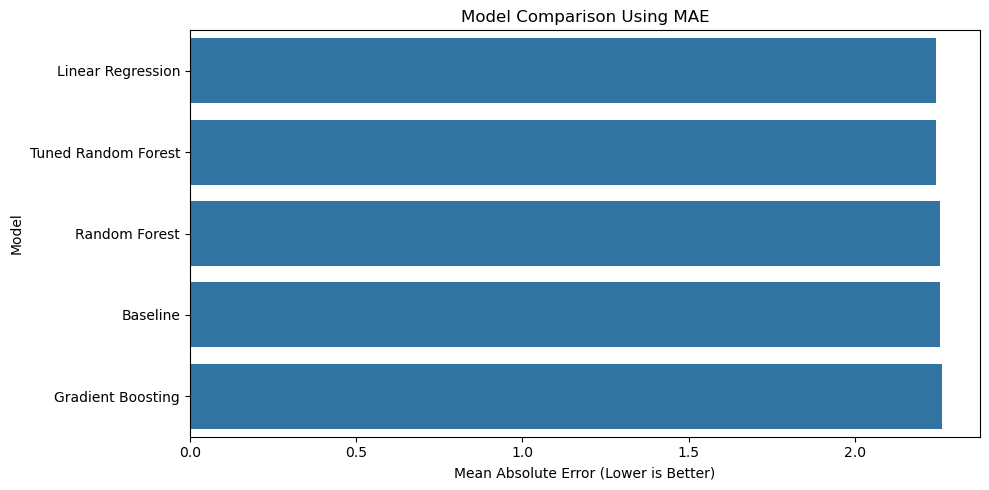

In [28]:
## Compare MAE across all models

plt.figure(figsize=(10, 5))

sns.barplot(
    data=final_results,
    x="MAE",
    y="Model"
)

plt.title("Model Comparison Using MAE")
plt.xlabel("Mean Absolute Error (Lower is Better)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

### Model Comparison Interpretation

The graph compares the Mean Absolute Error of all tested models.

The model bars are relatively similar, showing that none of the trained models
substantially outperformed the others.

This supports the conclusion that the weak results may be caused by limited
predictive relationships in the dataset rather than only by the selected
algorithm.

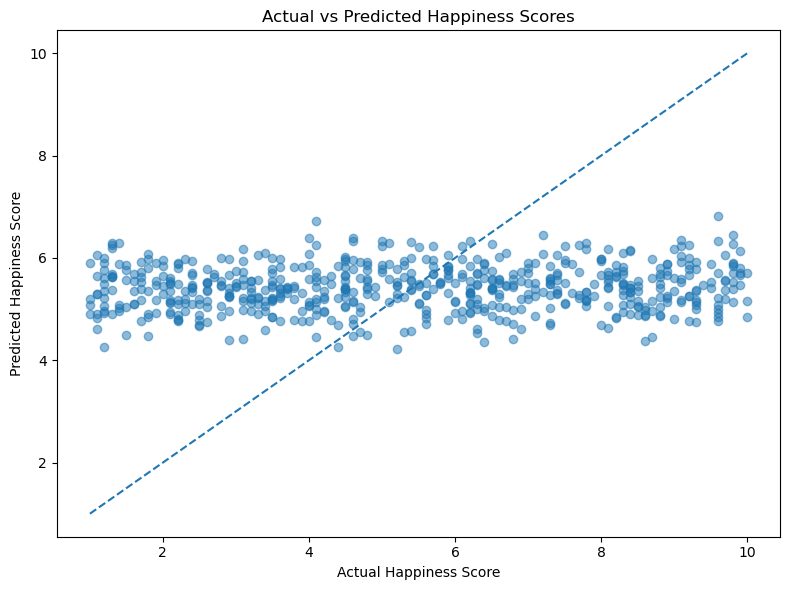

In [29]:
## Compare actual and predicted Happiness Scores

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.5
)

minimum_value = min(y_test.min(), tuned_predictions.min())
maximum_value = max(y_test.max(), tuned_predictions.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Happiness Scores")
plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.tight_layout()
plt.show()

### Residual Interpretation

Residuals represent the difference between the actual and predicted Happiness
Scores.

Residuals close to zero represent more accurate predictions. The wide spread
of residuals shows that the final model still produces substantial prediction
errors for some records.

This is consistent with the low R² score and confirms that the available
features have limited ability to explain the target.

### Actual Versus Predicted Values

A strong regression model would produce points close to the diagonal reference
line.

The predictions are concentrated within a narrower range than the actual
Happiness Scores. This indicates that the model often predicts values close to
the average and struggles to distinguish between participants with very low
and very high Happiness Scores.

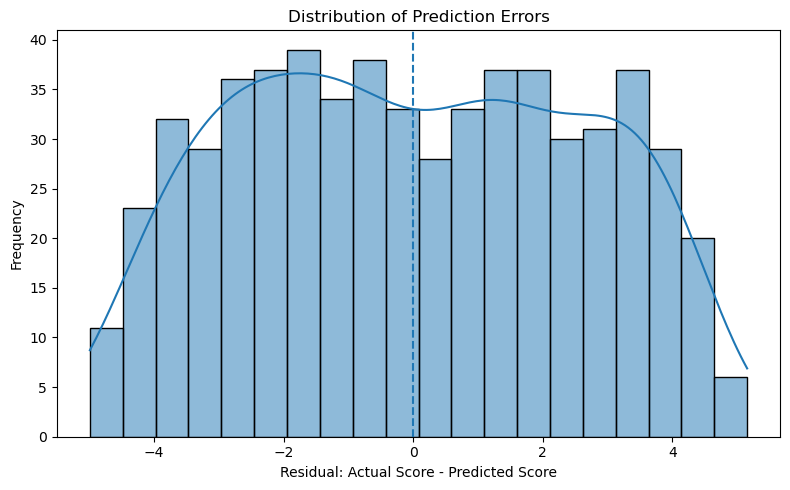

In [30]:
## Check the distribution of prediction errors

residuals = y_test - tuned_predictions

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual: Actual Score - Predicted Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [31]:
## Save the final trained model

import joblib

joblib.dump(
    tuned_model,
    "happiness_prediction_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
joblib.dump(tuned_model, "happiness_prediction_model.pkl")

['happiness_prediction_model.pkl']

### Model Export

The complete tuned pipeline was saved as
`happiness_prediction_model.pkl`.

The exported object contains both preprocessing and model-prediction steps.
This allows the Streamlit application to accept raw user inputs and apply the
same transformations used during model training.